# NYC 311 Noise Complaint Analysis

**Author:** Olivia Mohning  
**Last updated:** August 30, 2025  
**Dataset:** data_raw/311_noise_complaints_2024.csv

This project analyzes NYC 311 noise complaints to uncover patterns in when and where they occur, and builds a baseline forecast of complaint volumes. The results are designed to help inform resource allocation, highlight recurring hotspots, and demonstrate practical data analysis skills with Python, SQL, and visualization tools.

Key skills and tools: Python 3.11 (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`), SQL, Jupyter Notebooks, Tableau.

Scope and Deliverables
- Clean and prepare raw complaint data for analysis.
- Explore trends using descriptive statistics and visualizations.
- Build baseline time-series forecasts (seasonal-naive, SARIMA planned).
- Provide SQL query examples that aggregate and join processed data.
- Save clean datasets, key plots, and metrics for use in the README and dashboard.

Notes:
This notebook saves cleaned datasets to data_processed/ and key plots to assets/ for inclusion in the README and dashboard.

## Table of Contents
1. [Imports and Setup](#Imports-and-Setup)
2. [Data Preview & Basic Structure](#Data-Preview-&-Basic-Structure)
3. [Data Cleaning](#Data-Cleaning)
4. [Early Visualizations](#Early-Visualizations)
5. [Time-Based Trends](#Time-Based-Trends)
6. [Forecasting and Modeling](#Forecasting-and-Modeling) *(coming soon)*
7. [Conclusions and Next Steps](#Conclusions-and-Next-Steps) *(coming soon)*

## Imports and Setup

Load core libraries for data analysis.

In [1]:
# Imports
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Paths
ROOT = Path.cwd().resolve()
DATA_RAW = ROOT / "data_raw"
DATA_PROCESSED = ROOT / "data_processed"
ASSETS = ROOT / "assets"
for p in (DATA_PROCESSED, ASSETS):
    p.mkdir(parents=True, exist_ok=True)

# Reproducibility & display
np.random.seed(42)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
sns.set_theme()
warnings.filterwarnings("ignore")

# Versions
print(
    "Python:", sys.version.split()[0],
    "| numpy:", np.__version__,
    "| pandas:", pd.__version__,
    "| matplotlib:", plt.matplotlib.__version__,
    "| seaborn:", sns.__version__,
    "| sqlite3:", sqlite3.sqlite_version
)

Python: 3.11.13 | numpy: 2.3.2 | pandas: 2.3.1 | matplotlib: 3.10.5 | seaborn: 0.13.2 | sqlite3: 3.50.4


## Data Preview & Basic Structure

Load the dataset, preview its dimensions, and inspect the columns to get a sense of the data. Running the below code snippet, we can see that the dataset is much smaller sample of the original data. This sample was pulled in late July 2025, and includes only 20,000 observations for ease of use.

In [2]:
# Loading in a random sample of 20,000 instances from the NYC 311 noise complaint public dataset
df = pd.read_csv("../data_raw/311_noise_complaints_2024.csv")

# Preview dataset size
print(f"Dataset shape: {df.shape}")

Dataset shape: (753258, 41)


In [3]:
print(df.columns.tolist())

['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name', 'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip', 'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2', 'Intersection Street 1', 'Intersection Street 2', 'Address Type', 'City', 'Landmark', 'Facility Type', 'Status', 'Due Date', 'Resolution Description', 'Resolution Action Updated Date', 'Community Board', 'BBL', 'Borough', 'X Coordinate (State Plane)', 'Y Coordinate (State Plane)', 'Open Data Channel Type', 'Park Facility Name', 'Park Borough', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment', 'Latitude', 'Longitude', 'Location']


In [4]:
# Normalize column names
df.columns = (
    df.columns
    .str.strip()                     # remove leading/trailing whitespace
    .str.lower()                     # lowercase everything
    .str.replace(" ", "_")           # replace spaces with underscores
    .str.replace(r"[()]", "", regex=True)  # remove parentheses
)

print(df.columns.tolist())

['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name', 'complaint_type', 'descriptor', 'location_type', 'incident_zip', 'incident_address', 'street_name', 'cross_street_1', 'cross_street_2', 'intersection_street_1', 'intersection_street_2', 'address_type', 'city', 'landmark', 'facility_type', 'status', 'due_date', 'resolution_description', 'resolution_action_updated_date', 'community_board', 'bbl', 'borough', 'x_coordinate_state_plane', 'y_coordinate_state_plane', 'open_data_channel_type', 'park_facility_name', 'park_borough', 'vehicle_type', 'taxi_company_borough', 'taxi_pick_up_location', 'bridge_highway_name', 'bridge_highway_direction', 'road_ramp', 'bridge_highway_segment', 'latitude', 'longitude', 'location']


In [5]:
# Looking at a sample of the data
df.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,63576192,12/31/2024 11:58:55 PM,01/02/2025 05:05:54 PM,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,10466.0,655 EAST 230 STREET,EAST 230 STREET,CARPENTER AVENUE,LOWERRE PLACE,CARPENTER AVENUE,LOWERRE PLACE,ADDRESS,BRONX,EAST 230 STREET,NaN,Closed,NaN,The Police Department responded to the complai...,01/02/2025 05:08:14 PM,12 BRONX,2.048330e+09,BRONX,1022911.0,264242.0,MOBILE,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.891872,-73.860168,"(40.89187241649303, -73.86016845296459)"
1,63578152,12/31/2024 11:58:49 PM,01/01/2025 02:07:20 AM,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,Residential Building/House,11417.0,96-25 ROCKAWAY BOULEVARD,ROCKAWAY BOULEVARD,97 STREET,98 STREET,97 STREET,98 STREET,ADDRESS,OZONE PARK,ROCKAWAY BOULEVARD,NaN,Closed,NaN,The Police Department responded to the complai...,01/01/2025 02:07:24 AM,10 QUEENS,4.091690e+09,QUEENS,1028071.0,187175.0,ONLINE,Unspecified,QUEENS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.680320,-73.842008,"(40.68032043275897, -73.842008218077)"
2,63583269,12/31/2024 11:58:45 PM,01/01/2025 08:38:07 AM,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,10466.0,655 EAST 230 STREET,EAST 230 STREET,CARPENTER AVENUE,LOWERRE PLACE,CARPENTER AVENUE,LOWERRE PLACE,ADDRESS,BRONX,EAST 230 STREET,NaN,Closed,NaN,The Police Department responded to the complai...,01/01/2025 08:38:11 AM,12 BRONX,2.048330e+09,BRONX,1022911.0,264242.0,MOBILE,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.891872,-73.860168,"(40.89187241649303, -73.86016845296459)"
3,63575575,12/31/2024 11:58:34 PM,01/01/2025 12:05:49 AM,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,Residential Building/House,11211.0,218 SOUTH THIRD STREET,SOUTH THIRD STREET,ROEBLING STREET,HAVEMEYER STREET,ROEBLING STREET,HAVEMEYER STREET,ADDRESS,BROOKLYN,SOUTH 3 STREET,NaN,Closed,NaN,The Police Department responded to the complai...,01/01/2025 12:05:54 AM,01 BROOKLYN,3.024330e+09,BROOKLYN,995624.0,198392.0,MOBILE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.711210,-73.958973,"(40.71120965026345, -73.95897331500413)"
4,63584539,12/31/2024 11:58:33 PM,01/01/2025 12:35:03 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10029.0,335 EAST 112 STREET,EAST 112 STREET,2 AVENUE,THOMAS JEFFERSON PARK PATH,2 AVENUE,THOMAS JEFFERSON PARK PATH,ADDRESS,NEW YORK,EAST 112 STREET,NaN,Closed,NaN,The Police Department responded to the complai...,01/01/2025 12:35:11 AM,11 MANHATTAN,1.016840e+09,MANHATTAN,1001349.0,228522.0,MOBILE,Unspecified,MANHATTAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.793900,-73.938246,"(40.79389962799122, -73.93824629300637)"


In [6]:
# Column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753258 entries, 0 to 753257
Data columns (total 41 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   unique_key                      753258 non-null  int64  
 1   created_date                    753258 non-null  object 
 2   closed_date                     749392 non-null  object 
 3   agency                          753258 non-null  object 
 4   agency_name                     753258 non-null  object 
 5   complaint_type                  753258 non-null  object 
 6   descriptor                      753258 non-null  object 
 7   location_type                   697736 non-null  object 
 8   incident_zip                    753159 non-null  float64
 9   incident_address                747862 non-null  object 
 10  street_name                     747840 non-null  object 
 11  cross_street_1                  746548 non-null  object 
 12  cross_street_2  

## Mini "Codebook"

Below is a reference key describing the columns, adapted from the [NYC Open Data documentation](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2010-to-Present/erm2-nwe9/data_dictionary).

- **unique_key**: Unique identifier for each service request  
- **created_date**: Date and time the complaint was created  
- **closed_date**: Date and time the complaint was closed (if closed)  
- **agency**: Code for the agency handling the complaint  
- **agency_name**: Full name of the agency  
- **complaint_type**: General category of the complaint (e.g., "Noise")  
- **descriptor**: More detailed sub-category of the complaint  
- **location_type**: Type of location (e.g., residential building, street, etc.)  
- **incident_zip**: ZIP code where the incident occurred  
- **incident_address**: Street address where the complaint occurred  
- **street_name**: Street name only  
- **cross_street_1** / **cross_street_2**: Intersecting streets near the incident  
- **intersection_street_1** / **intersection_street_2**: Alternate fields for intersection location  
- **address_type**: How the address was provided (e.g., exact, intersection, etc.)  
- **city**: Name of the city the incident occurred in  
- **landmark**: Noted nearby landmark (if applicable)  
- **facility_type**: Type of facility involved (very sparse)  
- **status**: Current status of the complaint (e.g., “Closed”, “Open”)  
- **due_date**: When the agency aimed to resolve the issue by (rarely filled)  
- **resolution_description**: Description of the resolution or response  
- **resolution_action_updated_date**: Timestamp of last resolution update  
- **community_board**: Community board jurisdiction  
- **bbl**: Borough-Block-Lot code (for NYC land lots)  
- **borough**: NYC borough (Manhattan, Bronx, etc.)  
- **x_coordinate_state_plane** / **y_coordinate_state_plane**: NYC-specific coordinates  
- **open_data_channel_type**: How the complaint was submitted (phone, app, etc.)  
- **park_facility_name**: Park facility name (if applicable)  
- **park_borough**: Borough assigned to the park  
- **vehicle_type**: Type of vehicle involved (sparse)  
- **taxi_company_borough**: Borough of taxi company (rare)  
- **taxi_pick_up_location**: Taxi pick-up area (rare)  
- **bridge_highway_name**, **bridge_highway_direction**, **road_ramp**, **bridge_highway_segment**: Location data for complaints on highways/bridges (rare)  
- **latitude** / **longitude**: Geographic coordinates  
- **location**: Combined lat/long string


## Data Cleaning
1. Check the complaint_type value counts of the original dataset.
2. Save a copy of the original dataframe, df, to noise_df, which will include only the rows where the complaint_type column includes the word "noise" - indiscriminate of the string's case. Check complaint_type value counts for noise_df.
3. Drop the now empty columns from df where complaint_type did not include the word "noise." These columns are now empty and safe to drop.
4. Check for any redundant entries, or duplicate rows.
5. Check if any columns have a disproportionately large number of NULL values and deal with them accordingly.

In [7]:
# 1. Checking the complaint_type value counts of our original dataset
df['complaint_type'].value_counts()

complaint_type
Noise - Residential         379292
Noise - Street/Sidewalk     163002
Noise - Commercial           68347
Noise                        55522
Noise - Vehicle              48834
Noise - Helicopter           28686
Noise - Park                  8279
Noise - House of Worship      1296
Name: count, dtype: int64

In [8]:
# 2. Saving a copy of df as noise_df, including only noise-related complaint types, and checking the complaint_type value counts
noise_df = df[df['complaint_type'].str.contains("noise", case=False, na=False)].copy()

noise_df['complaint_type'].value_counts()

complaint_type
Noise - Residential         379292
Noise - Street/Sidewalk     163002
Noise - Commercial           68347
Noise                        55522
Noise - Vehicle              48834
Noise - Helicopter           28686
Noise - Park                  8279
Noise - House of Worship      1296
Name: count, dtype: int64

In [9]:
# 3. Dropping columns where every value is now null after filtering for just noise complaints and checking the shape
noise_df = noise_df.dropna(axis=1, how='all')

noise_df.shape

(753258, 33)

In [10]:
# 4. Checking for redundant entries
dupes = noise_df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

Duplicate rows: 0


In [11]:
# 5. Check if any columns contain a disproportionately large number of NULL values
null_pct = (noise_df.isna().mean() * 100).round(2)
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
null_pct_formatted = null_pct.astype(str) + '%'
print(null_pct_formatted)

vehicle_type                      93.52%
landmark                          10.96%
bbl                                7.47%
location_type                      7.37%
intersection_street_1              6.82%
intersection_street_2              6.78%
city                               3.59%
cross_street_1                     0.89%
cross_street_2                     0.86%
resolution_description             0.81%
incident_address                   0.72%
street_name                        0.72%
closed_date                        0.51%
resolution_action_updated_date     0.51%
x_coordinate_state_plane            0.5%
y_coordinate_state_plane            0.5%
latitude                            0.5%
longitude                           0.5%
location                            0.5%
incident_zip                       0.01%
dtype: object


Above, we see the column, vehicle_type, contains over 90% NULL values. This is likely because the only complaint types that would need to include a vehicle type are the 349 "Noise - Vehicle" complaint types. Let's confirm that first:

In [12]:
# 5a. Complaints where complaint_type IS "Noise - Vehicle"
vehicle_only = noise_df[noise_df['complaint_type'] == "Noise - Vehicle"]
vehicle_only_null_pct = (vehicle_only['vehicle_type'].isna().mean() * 100).round(2)
print(f"NULLs in vehicle_type where complaint_type is 'Noise - Vehicle': {vehicle_only_null_pct}%")

# Complaints where complaint_type is NOT "Noise - Vehicle"
non_vehicle = noise_df[noise_df['complaint_type'] != "Noise - Vehicle"]
non_vehicle_null_pct = (non_vehicle['vehicle_type'].isna().mean() * 100).round(2)
print(f"NULLs in vehicle_type where complaint_type is NOT 'Noise - Vehicle': {non_vehicle_null_pct}% \n")

NULLs in vehicle_type where complaint_type is 'Noise - Vehicle': 0.0%
NULLs in vehicle_type where complaint_type is NOT 'Noise - Vehicle': 100.0% 



In [13]:
# 5b. Filter rows for NULLs
null_column = noise_df[noise_df["bbl"].isna()]
null_column = noise_df[noise_df["landmark"].isna()]
null_column = noise_df[noise_df["intersection_street_2"].isna()]
null_column = noise_df[noise_df["intersection_street_1"].isna()]
null_column = noise_df[noise_df["city"].isna()]
null_column = noise_df[noise_df["closed_date"].isna()]
null_column = noise_df[noise_df["resolution_description"].isna()]
null_column = noise_df[noise_df["resolution_action_updated_date"].isna()]
null_column = noise_df[noise_df["x_coordinate_state_plane"].isna()]
null_column = noise_df[noise_df["y_coordinate_state_plane"].isna()]
null_column = noise_df[noise_df["cross_street_2"].isna()]
null_column = noise_df[noise_df["cross_street_1"].isna()]
null_column = noise_df[noise_df["street_name"].isna()]
null_column = noise_df[noise_df["incident_address"].isna()]
null_column = noise_df[noise_df["address_type"].isna()]
null_column = noise_df[noise_df["incident_zip"].isna()]

print("Complaint Type counts:")
print(null_column["complaint_type"].value_counts(), "\n")

print("Descriptor counts:")
print(null_column["descriptor"].value_counts(), "\n")

print("Location Type counts:")
print(null_column["location_type"].value_counts(), "\n")

Complaint Type counts:
complaint_type
Noise - Residential        42
Noise - Park               24
Noise - Street/Sidewalk    12
Noise                       8
Noise - Vehicle             6
Noise - Commercial          4
Noise - Helicopter          3
Name: count, dtype: int64 

Descriptor counts:
descriptor
Loud Music/Party                                44
Banging/Pounding                                26
Loud Talking                                    12
Noise: Construction Before/After Hours (NM1)     6
Engine Idling                                    2
Car/Truck Music                                  2
Other                                            2
Car/Truck Horn                                   2
Noise: Jack Hammering (NC2)                      1
Noise: Boat(Engine,Music,Etc) (NR10)             1
NYPD                                             1
Name: count, dtype: int64 

Location Type counts:
location_type
Residential Building/House    42
Park/Playground               24
Str

Looking at the above value counts, we can see that bbl, landmark, intersection_street_2, intersection_street_1, city, closed_date, resolution_description, resolution_action_updated_date, x_coordinate_state_plane, y_coordinate_state_plane, cross_street_2, cross_street_1, street_name, incident_address, address_type, and incident_zip don't tell us much of anything that other columns (that we will keep) tell us, so we are fine to drop them.

In [14]:
# Drop redundant or low-value columns
cols_to_drop = [
    "bbl", "landmark", "intersection_street_2", "intersection_street_1",
    "city", "closed_date", "resolution_description", 
    "resolution_action_updated_date", "x_coordinate_state_plane", 
    "y_coordinate_state_plane", "cross_street_2", "cross_street_1", 
    "street_name", "incident_address", "address_type", "incident_zip"
]

noise_df_cleaned = noise_df.drop(columns=cols_to_drop)

In [15]:
print("Dropped columns:", cols_to_drop)
print("\n Remaining columns:", noise_df_cleaned.columns.tolist())

Dropped columns: ['bbl', 'landmark', 'intersection_street_2', 'intersection_street_1', 'city', 'closed_date', 'resolution_description', 'resolution_action_updated_date', 'x_coordinate_state_plane', 'y_coordinate_state_plane', 'cross_street_2', 'cross_street_1', 'street_name', 'incident_address', 'address_type', 'incident_zip']

 Remaining columns: ['unique_key', 'created_date', 'agency', 'agency_name', 'complaint_type', 'descriptor', 'location_type', 'status', 'community_board', 'borough', 'open_data_channel_type', 'park_facility_name', 'park_borough', 'vehicle_type', 'latitude', 'longitude', 'location']


## Further Data Cleaning

Some findings from the below random sample of instances, and plan of action for more cleaning:
1. `created_date`: In datetime64, may need conversion.
2. `agency` and `agency_name`: Redundant; probably not useful for filtering or analysis. Drop both.
3. `complaint_type` and `descriptor`: Rich source of info. Good candidates for grouping/severity classification later.
4. `location_type`: Potentially interesting; might correlate with complaint_type or borough.
5. `status`, `community_board`: Don't care about it. Drop it.
6. `borough`: Definitely useful. Central for geographic analysis.
7. `open_data_channel_type`: Not interested for the purpose of this analysis. Drop it.
8. `park_facility_name`: Likely just noise, consider dropping.
9. `park_borough`: Redundant after borough, drop it.
10. `vehicle_type`: Mostly full of NULLs, also irrelevant. Drop it.
11. `latitude`, `longitutde`, and `location`: Keep. Location more precise than latitude and longitude.

In [16]:
noise_df_cleaned.head()

,unique_key,created_date,agency,agency_name,complaint_type,descriptor,location_type,status,community_board,borough,open_data_channel_type,park_facility_name,park_borough,vehicle_type,latitude,longitude,location
0,63576192,12/31/2024 11:58:55 PM,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,Closed,12 BRONX,BRONX,MOBILE,Unspecified,BRONX,NaN,40.891872,-73.860168,"(40.89187241649303, -73.86016845296459)"
1,63578152,12/31/2024 11:58:49 PM,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,Residential Building/House,Closed,10 QUEENS,QUEENS,ONLINE,Unspecified,QUEENS,NaN,40.680320,-73.842008,"(40.68032043275897, -73.842008218077)"
2,63583269,12/31/2024 11:58:45 PM,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,Closed,12 BRONX,BRONX,MOBILE,Unspecified,BRONX,NaN,40.891872,-73.860168,"(40.89187241649303, -73.86016845296459)"
3,63575575,12/31/2024 11:58:34 PM,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,Residential Building/House,Closed,01 BROOKLYN,BROOKLYN,MOBILE,Unspecified,BROOKLYN,NaN,40.711210,-73.958973,"(40.71120965026345, -73.95897331500413)"
4,63584539,12/31/2024 11:58:33 PM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,Closed,11 MANHATTAN,MANHATTAN,MOBILE,Unspecified,MANHATTAN,NaN,40.793900,-73.938246,"(40.79389962799122, -73.93824629300637)"


In [17]:
# 1. Converting created_date to datetime for later tests
noise_df_cleaned['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')

# Confirming created_date is in datetime
print(noise_df_cleaned['created_date'].dtype)
# expected: datetime64[ns]

# Looking for any non-datetime rows that didn't get parsed
bad_dates = noise_df_cleaned['created_date'].apply(lambda x: isinstance(x, str)).sum()
print(f"Non-datetime entries: {bad_dates}")

datetime64[ns]
Non-datetime entries: 0


In [18]:
# 2a. Group by agency and see how many unique agency_name values each has
check = noise_df_cleaned.groupby("agency")["agency_name"].nunique()

print(check)

# Show any agencies that map to more than one agency_name
print("\nAgencies with multiple names:")
print(check[check > 1])

agency
3-1-1    1
DEP      1
EDC      1
NYPD     1
Name: agency_name, dtype: int64

Agencies with multiple names:
Series([], Name: agency_name, dtype: int64)


In [19]:
# 2b. Dropping agency_name because it's longer and more annoying to type out than agency
noise_df_cleaned = noise_df_cleaned.drop(columns=["agency_name"])

In [20]:
noise_df_cleaned.head()

,unique_key,created_date,agency,complaint_type,descriptor,location_type,status,community_board,borough,open_data_channel_type,park_facility_name,park_borough,vehicle_type,latitude,longitude,location
0,63576192,2024-12-31 23:58:55,NYPD,Noise - Residential,Loud Music/Party,Residential Building/House,Closed,12 BRONX,BRONX,MOBILE,Unspecified,BRONX,NaN,40.891872,-73.860168,"(40.89187241649303, -73.86016845296459)"
1,63578152,2024-12-31 23:58:49,NYPD,Noise - Residential,Banging/Pounding,Residential Building/House,Closed,10 QUEENS,QUEENS,ONLINE,Unspecified,QUEENS,NaN,40.680320,-73.842008,"(40.68032043275897, -73.842008218077)"
2,63583269,2024-12-31 23:58:45,NYPD,Noise - Residential,Loud Music/Party,Residential Building/House,Closed,12 BRONX,BRONX,MOBILE,Unspecified,BRONX,NaN,40.891872,-73.860168,"(40.89187241649303, -73.86016845296459)"
3,63575575,2024-12-31 23:58:34,NYPD,Noise - Residential,Banging/Pounding,Residential Building/House,Closed,01 BROOKLYN,BROOKLYN,MOBILE,Unspecified,BROOKLYN,NaN,40.711210,-73.958973,"(40.71120965026345, -73.95897331500413)"
4,63584539,2024-12-31 23:58:33,NYPD,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,Closed,11 MANHATTAN,MANHATTAN,MOBILE,Unspecified,MANHATTAN,NaN,40.793900,-73.938246,"(40.79389962799122, -73.93824629300637)"


In [21]:
# 3. Looking at complaint_type and descriptor to see what's there
display(noise_df_cleaned['complaint_type'].value_counts())
display(noise_df_cleaned['descriptor'].value_counts())

complaint_type
Noise - Residential         379292
Noise - Street/Sidewalk     163002
Noise - Commercial           68347
Noise                        55522
Noise - Vehicle              48834
Noise - Helicopter           28686
Noise - Park                  8279
Noise - House of Worship      1296
Name: count, dtype: int64

descriptor
Loud Music/Party                                    424139
Banging/Pounding                                    119835
Loud Talking                                         68823
Car/Truck Music                                      30608
Other                                                28038
Noise: Construction Before/After Hours (NM1)         22643
Engine Idling                                        10112
Car/Truck Horn                                        9350
Noise, Barking Dog (NR5)                              8327
Noise: Construction Equipment (NC1)                   7761
Loud Television                                       6174
Noise: Alarms (NR3)                                   5549
Noise: air condition/ventilation equipment (NV1)      4235
Noise: Jack Hammering (NC2)                           2588
Noise:  lawn care equipment (NCL)                     1309
Noise, Ice Cream Truck (NR4)                          1265
Noise: Private Carting Noise (NQ1)           

In [22]:
# 4. Looking at location_type to see what's there
display(noise_df_cleaned['location_type'].value_counts(dropna=False).head(10))

location_type
Residential Building/House    379291
Street/Sidewalk               211836
NaN                            55522
Store/Commercial               36308
Club/Bar/Restaurant            32039
Above Address                  28686
Park/Playground                 8279
House of Worship                1296
Building Condition                 1
Name: count, dtype: int64

In [23]:
# Explore rows where location_type is missing (NaN)
nan_loc = noise_df_cleaned[noise_df_cleaned['location_type'].isna()]

# How are the NaNs distributed across complaint types?
print("\nNaN location_type by complaint_type:")
display(nan_loc['complaint_type'].value_counts())

# Peek at a few examples
display(nan_loc[['created_date', 'borough', 'complaint_type', 'descriptor']].head(10))


NaN location_type by complaint_type:


complaint_type
Noise    55522
Name: count, dtype: int64

,created_date,borough,complaint_type,descriptor
17,2024-12-31 23:56:00,MANHATTAN,Noise,Noise: air condition/ventilation equipment (NV1)
468,2024-12-31 22:47:00,STATEN ISLAND,Noise,Noise: Alarms (NR3)
601,2024-12-31 22:26:00,MANHATTAN,Noise,Noise: Construction Equipment (NC1)
674,2024-12-31 22:14:00,STATEN ISLAND,Noise,"Noise, Barking Dog (NR5)"
743,2024-12-31 22:02:00,STATEN ISLAND,Noise,"Noise, Barking Dog (NR5)"
863,2024-12-31 21:41:00,BRONX,Noise,"Noise, Barking Dog (NR5)"
1042,2024-12-31 21:08:00,QUEENS,Noise,Noise: Construction Before/After Hours (NM1)
1499,2024-12-31 19:47:00,QUEENS,Noise,Noise: Construction Equipment (NC1)
1658,2024-12-31 19:20:00,MANHATTAN,Noise,Noise: Construction Equipment (NC1)
1822,2024-12-31 18:47:00,MANHATTAN,Noise,"Noise, Barking Dog (NR5)"


In the above sample of instances, we see that there are NaN values in the `location_type` column, which all fall under wherever `complaint_type` is just "Noise." We'll deal with this in a bit. First, we'll compare `location_type` and `complaint_type` to check for any overlapping information that may be redundant, as well as any information that is found in one column but not the other.

In [24]:
# Running a cross-tab to check overlap between complaint_type and location_type
ctab = pd.crosstab(noise_df_cleaned['complaint_type'], noise_df_cleaned['location_type'], normalize='index')  # row-wise %
display(ctab.round(2))

location_type,Above Address,Building Condition,Club/Bar/Restaurant,House of Worship,Park/Playground,Residential Building/House,Store/Commercial,Street/Sidewalk
complaint_type,,,,,,,,
Noise - Commercial,0.0,0.0,0.47,0.0,0.0,0.0,0.53,0.0
Noise - Helicopter,1.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0
Noise - House of Worship,0.0,0.0,0.00,1.0,0.0,0.0,0.00,0.0
Noise - Park,0.0,0.0,0.00,0.0,1.0,0.0,0.00,0.0
Noise - Residential,0.0,0.0,0.00,0.0,0.0,1.0,0.00,0.0
Noise - Street/Sidewalk,0.0,0.0,0.00,0.0,0.0,0.0,0.00,1.0
Noise - Vehicle,0.0,0.0,0.00,0.0,0.0,0.0,0.00,1.0


Indeed, notice that the above table shows a lot of overlap between `complaint_type` and `location_type`. We will clean this up for ease of use. Some notes on how we'll tackle that:
1. I find "complaint_type" more explanatory than "location_type" so I'd like to remove "location_type" if possible.
2. Before I remove "location_type," I want to separate out the "Noise - Commercial" complaint_type into "Club/Bar/Restaurant" and "Store/Commercial" which are both varieties of location_type that I'd like to keep separate for further study.
3. Drop location_type all together.
4. Rename "Noise" to "Noise - Unspecified." This is where those NaN values for location_type were found. We've dropped location_type, so the NaNs are irrelevant, and it's safe to say we don't need to fill them as the type of noise was never specified in the data.
5. Finally, I'll remove "Noise - " as a prefix because it's now useless.

In [25]:
# Make a copy to avoid SettingWithCopyWarning
noise_df_cleaned = noise_df_cleaned.copy()

noise_df_cleaned.loc[
    (noise_df_cleaned['complaint_type'] == 'Noise - Commercial') & 
    (noise_df_cleaned['location_type'] == 'Club/Bar/Restaurant'), 
    'complaint_type'
] = 'Noise - Bar/Club/Restaurant'

noise_df_cleaned.loc[
    (noise_df_cleaned['complaint_type'] == 'Noise - Commercial') & 
    (noise_df_cleaned['location_type'] == 'Store/Commercial'), 
    'complaint_type'
] = 'Noise - Store/Commercial'

# Now drop location_type
noise_df_cleaned.drop(columns=['location_type'], inplace=True)

# Replace "Noise" with "Noise - Unspecified" and remove "Noise - " from prefixes of all values
noise_df_cleaned['complaint_type'] = noise_df_cleaned['complaint_type'].replace('Noise', 'Noise - Unspecified')
noise_df_cleaned['complaint_type'] = noise_df_cleaned['complaint_type'].str.replace('Noise - ', '', regex=False)

# Print all unique complaint types line by line
for complaint in sorted(noise_df_cleaned['complaint_type'].unique()):
    print(complaint)

Bar/Club/Restaurant
Helicopter
House of Worship
Park
Residential
Store/Commercial
Street/Sidewalk
Unspecified
Vehicle


In [26]:
# 5. Dropping unique key (don't need it), status, community_board, open_data_channel_type, park_facility_name, park_borough, vehicle_type
cols_to_drop = ["unique_key", "status", "community_board", "open_data_channel_type", 
                "park_facility_name", "park_borough", "vehicle_type"]

noise_df_cleaned = noise_df_cleaned.drop(columns=cols_to_drop)

print("Dropped columns:", cols_to_drop)
print("\nRemaining columns:", noise_df_cleaned.columns.tolist())

Dropped columns: ['unique_key', 'status', 'community_board', 'open_data_channel_type', 'park_facility_name', 'park_borough', 'vehicle_type']

Remaining columns: ['created_date', 'agency', 'complaint_type', 'descriptor', 'borough', 'latitude', 'longitude', 'location']


In [27]:
# Taking a look to ensure everything looks good
noise_df_cleaned.head()

,created_date,agency,complaint_type,descriptor,borough,latitude,longitude,location
0,2024-12-31 23:58:55,NYPD,Residential,Loud Music/Party,BRONX,40.891872,-73.860168,"(40.89187241649303, -73.86016845296459)"
1,2024-12-31 23:58:49,NYPD,Residential,Banging/Pounding,QUEENS,40.680320,-73.842008,"(40.68032043275897, -73.842008218077)"
2,2024-12-31 23:58:45,NYPD,Residential,Loud Music/Party,BRONX,40.891872,-73.860168,"(40.89187241649303, -73.86016845296459)"
3,2024-12-31 23:58:34,NYPD,Residential,Banging/Pounding,BROOKLYN,40.711210,-73.958973,"(40.71120965026345, -73.95897331500413)"
4,2024-12-31 23:58:33,NYPD,Street/Sidewalk,Loud Music/Party,MANHATTAN,40.793900,-73.938246,"(40.79389962799122, -73.93824629300637)"


## Early Visualizations
Following our more extensive data exploration and cleaning seen above, we will build some preliminary data visualizations to increase our understanding of where the noise is concentrated in space and time/seasonality.

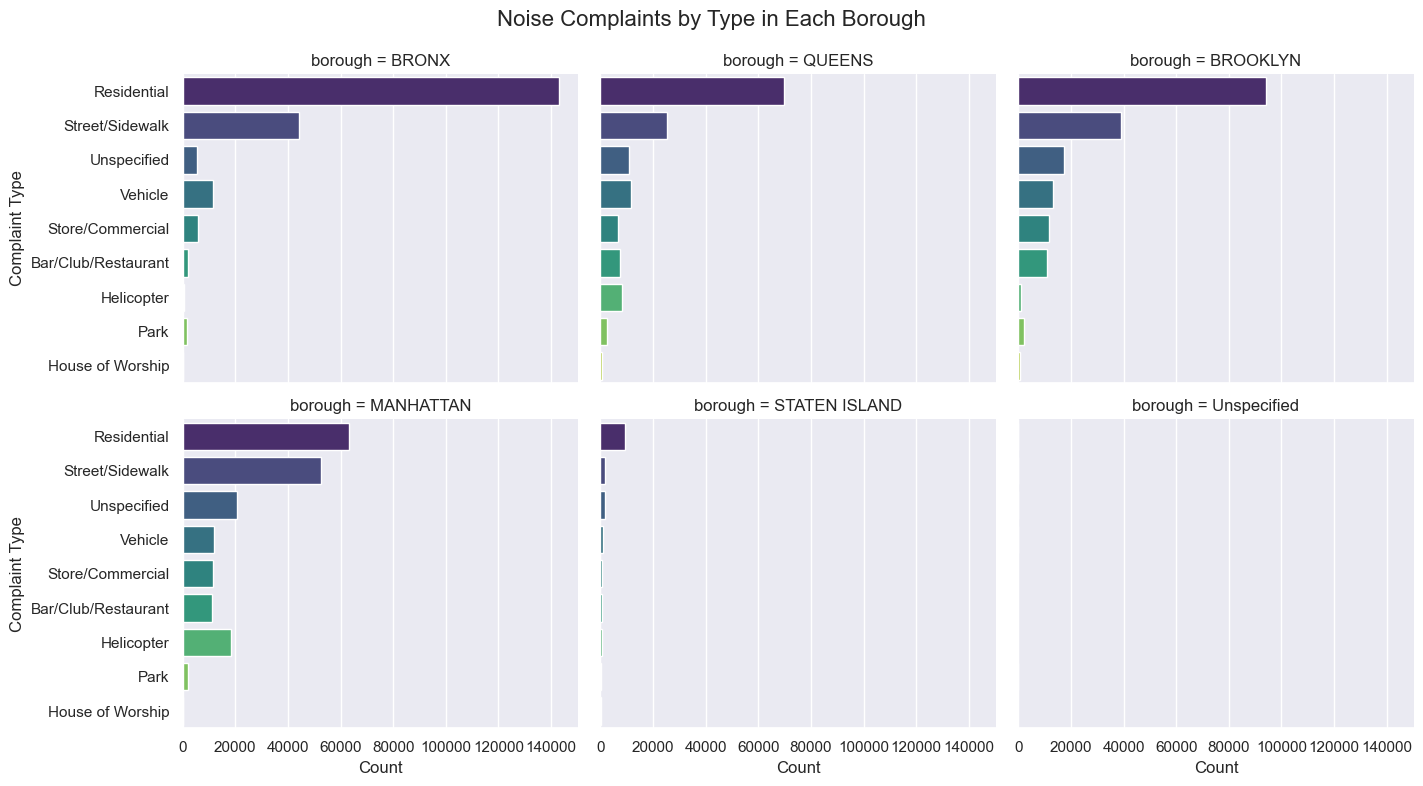

In [28]:
# Bar graphs of noise complaint types by borough (horizontal for readability)

complaint_order = noise_df_cleaned["complaint_type"].value_counts().index

# Create FacetGrid
g = sns.catplot(
    data=noise_df_cleaned,
    y="complaint_type",   # y instead of x -> horizontal bars
    kind="count",
    col="borough",
    col_wrap=3,
    order=complaint_order,
    height=4,
    aspect=1.2,
    palette="viridis"
)

# Set titles and labels
g.set_axis_labels("Count", "Complaint Type")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Noise Complaints by Type in Each Borough", fontsize=16)

plt.show()


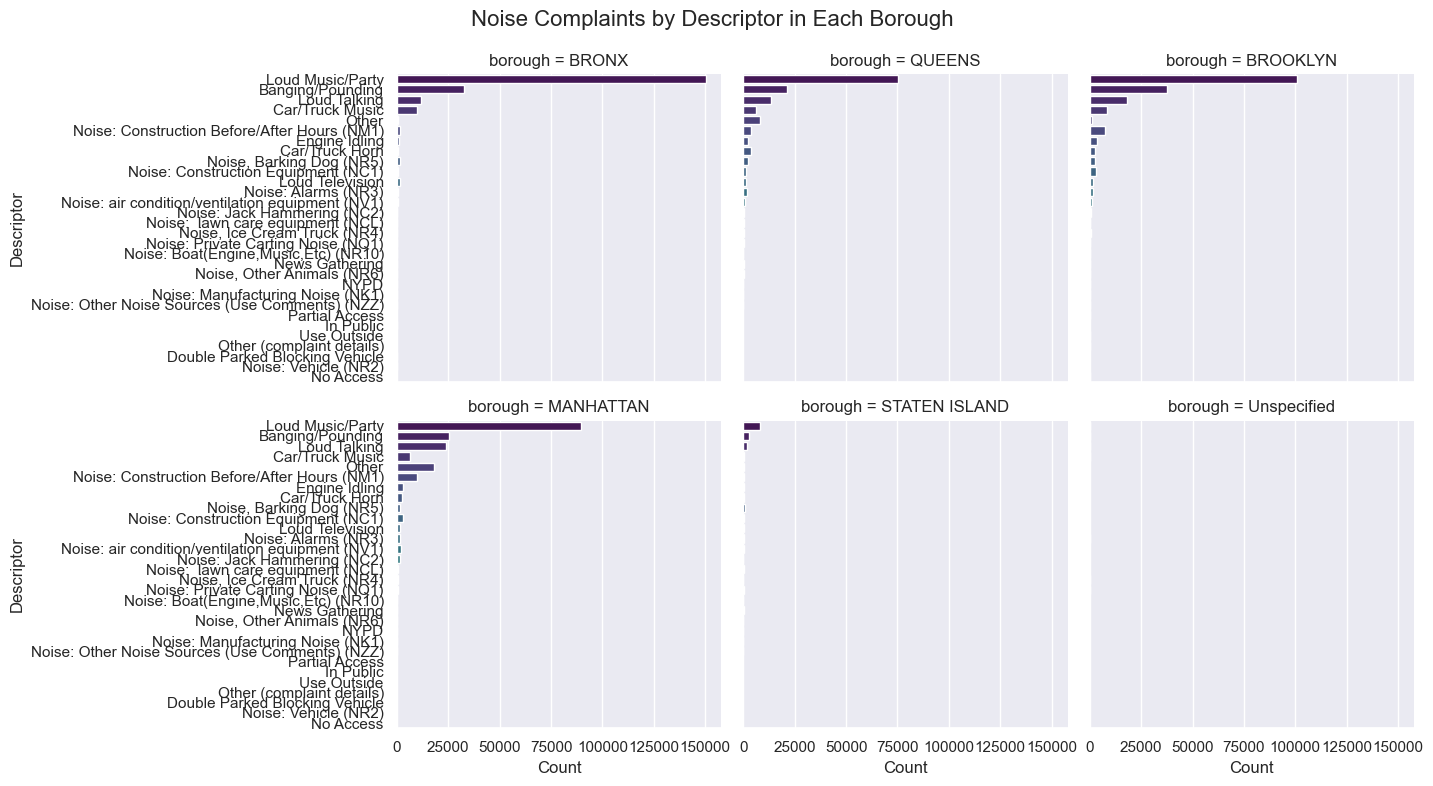

In [29]:
# Bar graphs of descriptor by borough (horizontal for readability)

descriptor_order = noise_df_cleaned["descriptor"].value_counts().index

# Create FacetGrid
g = sns.catplot(
    data=noise_df_cleaned,
    y="descriptor",   # y instead of x -> horizontal bars
    kind="count",
    col="borough",
    col_wrap=3,
    order=descriptor_order,
    height=4,
    aspect=1.2,
    palette="viridis"
)

# Set titles and labels
g.set_axis_labels("Count", "Descriptor")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Noise Complaints by Descriptor in Each Borough", fontsize=16)

plt.show()

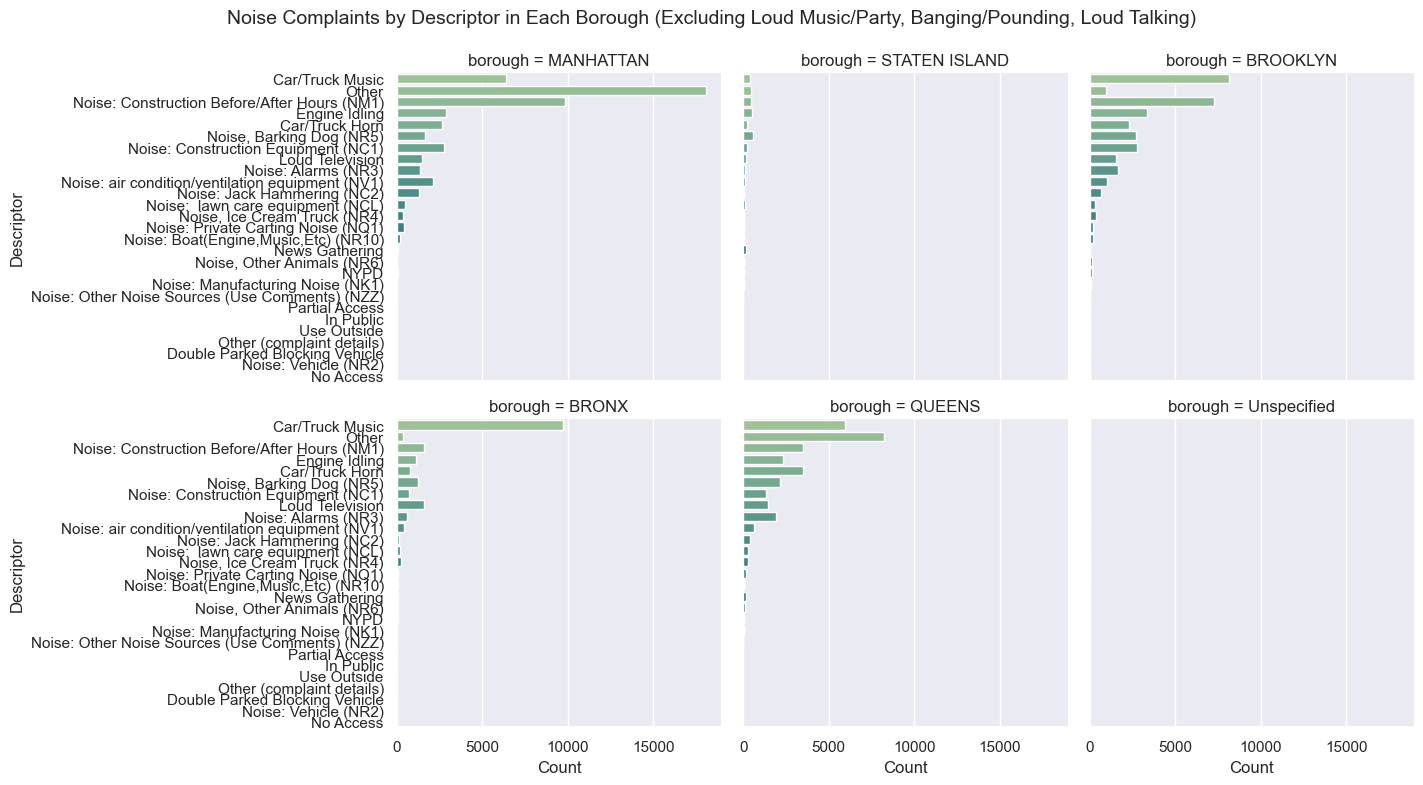

In [30]:
# Bar graphs of noise complaint descriptors by borough (excluding Loud Music/Party, Banging/Pounding, Loud Talking)

# Filter out top 3 overrepresented descriptors
exclude_descriptors = ["Loud Music/Party", "Banging/Pounding", "Loud Talking"]
df_filtered = noise_df_cleaned[~noise_df_cleaned["descriptor"].isin(exclude_descriptors)]

# Reorder descriptors by overall frequency (without excluded ones)
descriptor_order = df_filtered["descriptor"].value_counts().index

# Create FacetGrid
g = sns.catplot(
    data=df_filtered,
    y="descriptor",
    kind="count",
    col="borough",
    col_wrap=3,
    order=descriptor_order,
    height=4,
    aspect=1.2,
    palette="crest"
)

# Set labels and titles
g.set_axis_labels("Count", "Descriptor")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Noise Complaints by Descriptor in Each Borough (Excluding Loud Music/Party, Banging/Pounding, Loud Talking)", fontsize=14)

plt.show()


## Time-Based Trends
To better understand how noise complaints fluctuate over time, I analyzed the dataset at multiple temporal scales.

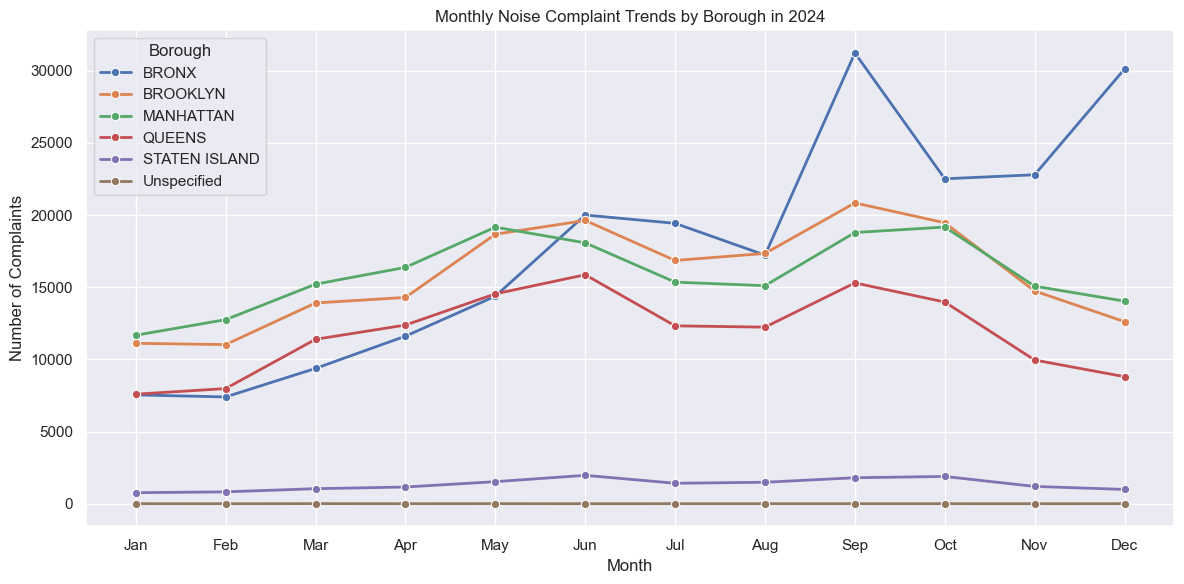

In [41]:
# --- Monthly Noise Complaint Trends in 2024 ---

# Ensure created_date is datetime
noise_df_cleaned["created_date"] = pd.to_datetime(noise_df_cleaned["created_date"], errors="coerce")

# Extract month number and month name
noise_df_cleaned["month"] = noise_df_cleaned["created_date"].dt.month
noise_df_cleaned["month_name"] = noise_df_cleaned["created_date"].dt.strftime("%b")
noise_df_cleaned["year"] = noise_df_cleaned["created_date"].dt.year

# Keep only 2024
noise_2024 = noise_df_cleaned[noise_df_cleaned["year"] == 2024]

# Ensure month order
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
noise_2024["month_name"] = pd.Categorical(noise_2024["month_name"], categories=month_order, ordered=True)

# Group by borough + month
monthly_counts = (
    noise_2024.groupby(["borough", "month_name"])
    .size()
    .reset_index(name="count")
)

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_counts, x="month_name", y="count", hue="borough", marker="o", lw=2)

plt.title("Monthly Noise Complaint Trends by Borough in 2024")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.legend(title="Borough")
plt.tight_layout()
plt.show()


### Monthly Trends
- Complaints rise gradually Jan to June, then there’s a big surge in September, especially in the Bronx.
- There's a rise when the weather is nice outside in late spring, early summer, and early fall. There's are dips when the weather is very warm or very cool outside. Winter months (Nov–Dec) are lower across all boroughs.
- The September surge is unusual. It may reflect specific events, reporting patterns, or data quirks (e.g., backlogs getting logged that month).

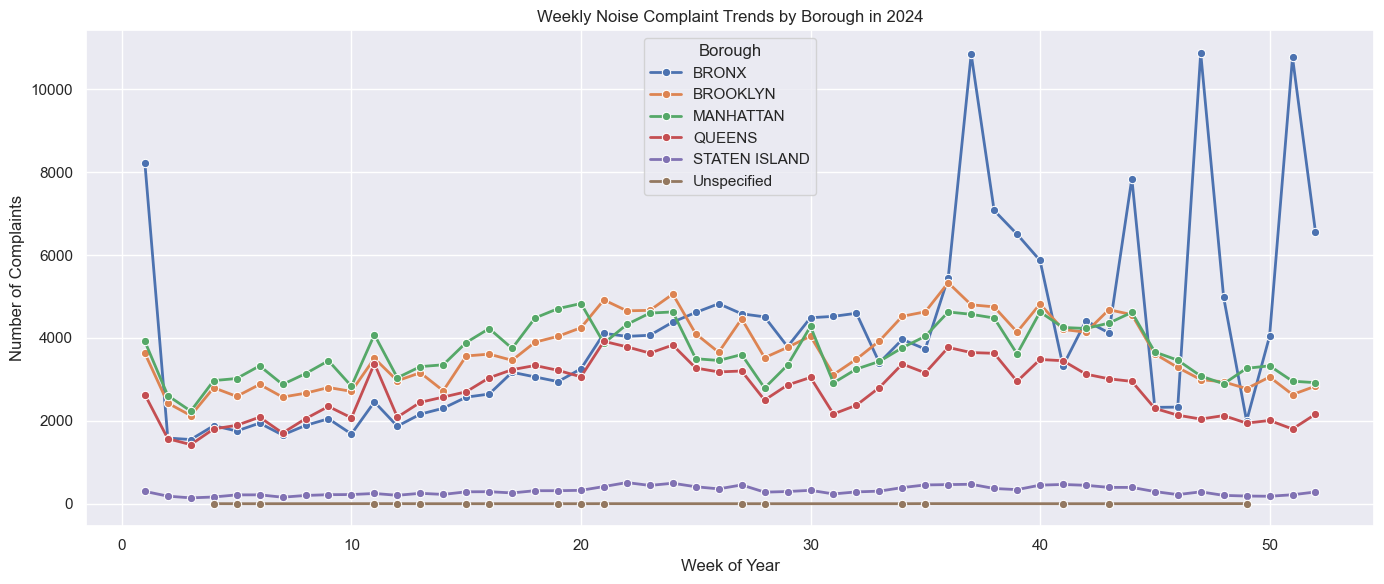

In [42]:
# --- Weekly Noise Complaint Trends in 2024 ---

# Extract ISO week number
noise_2024["week"] = noise_2024["created_date"].dt.isocalendar().week

# Group by borough + week
weekly_counts = (
    noise_2024.groupby(["borough", "week"])
    .size()
    .reset_index(name="count")
)

# Plot
plt.figure(figsize=(14,6))
sns.lineplot(data=weekly_counts, x="week", y="count", hue="borough", marker="o", lw=2)

plt.title("Weekly Noise Complaint Trends by Borough in 2024")
plt.xlabel("Week of Year")
plt.ylabel("Number of Complaints")
plt.legend(title="Borough")
plt.tight_layout()
plt.show()


### Weekly Trends
- Recurring “teeth” pattern - ups and downs most weeks, but not obviously pegged to major holidays.
- The Bronx shows very sharp peaks compared to other boroughs (could be reporting intensity differences).

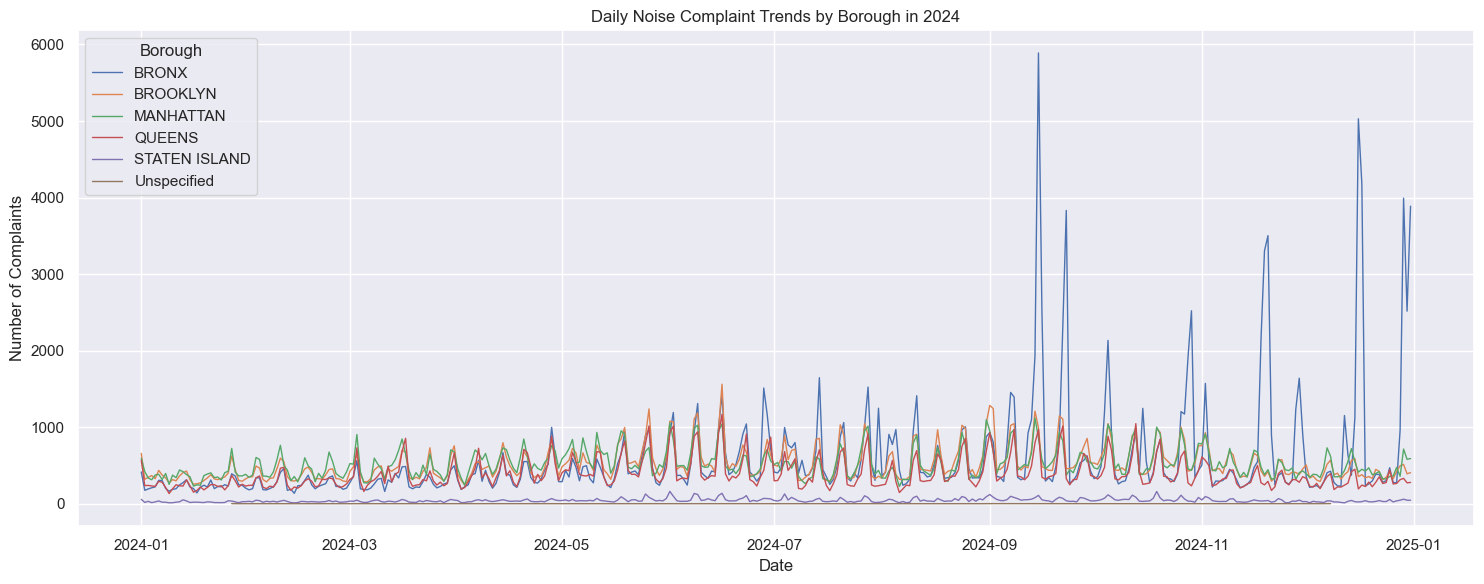

In [43]:
# --- Daily Noise Complaint Trends in 2024 ---

# Extract date (drop time)
noise_2024["date"] = noise_2024["created_date"].dt.date

# Group by borough + date
daily_counts = (
    noise_2024.groupby(["borough", "date"])
    .size()
    .reset_index(name="count")
)

# Plot
plt.figure(figsize=(15,6))
sns.lineplot(data=daily_counts, x="date", y="count", hue="borough", lw=1)

plt.title("Daily Noise Complaint Trends by Borough in 2024")
plt.xlabel("Date")
plt.ylabel("Number of Complaints")
plt.legend(title="Borough")
plt.tight_layout()
plt.show()


### Daily trends:
- Spikes are scattered throughout the year, not clustered exactly on July 4th or Dec 31st like one might expect. Likely this dataset reflects everyday residential + nightlife noise, not just holiday fireworks or parties.
- It could reflect weekend noise complaints.

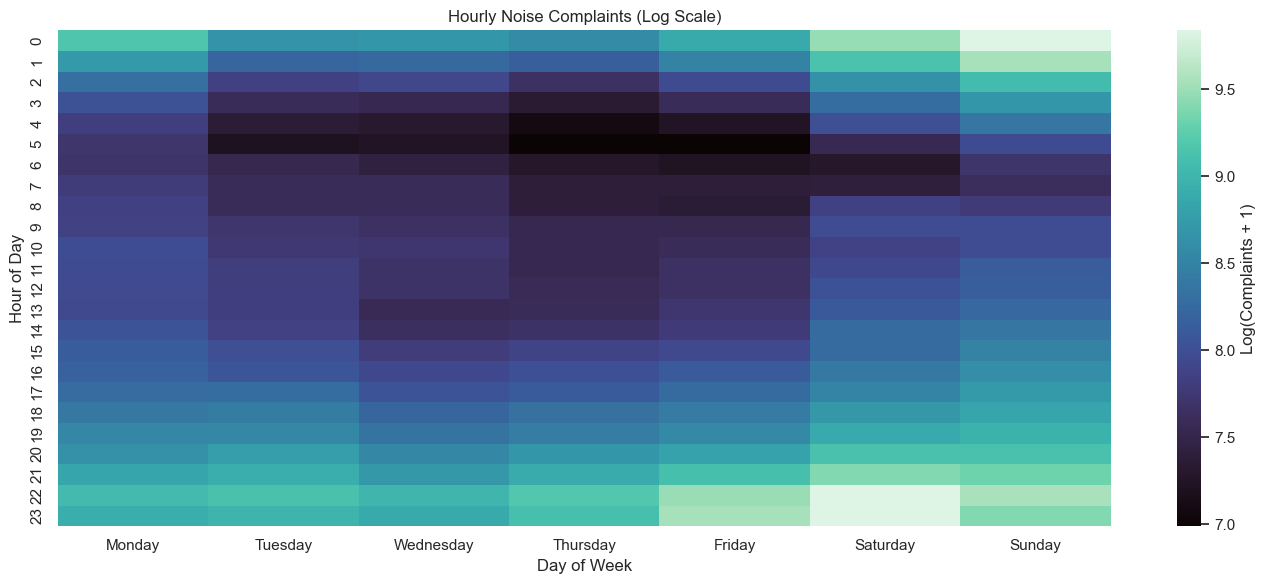

In [46]:
# --- Average Hourly Noise Complaint Trends in 2024 ---

# Extract hour of day and day of week
noise_df_cleaned["hour"] = noise_df_cleaned["created_date"].dt.hour
noise_df_cleaned["day_of_week"] = noise_df_cleaned["created_date"].dt.day_name()
noise_df_cleaned["year"] = noise_df_cleaned["created_date"].dt.year

# Keep only 2024
noise_2024 = noise_df_cleaned[noise_df_cleaned["year"] == 2024]

# Group by borough, day of week, and hour -> take average counts
hourly_counts = (
    noise_2024.groupby(["borough", "day_of_week", "hour"])
    .size()
    .reset_index(name="count")
)

# Ensure correct weekday order
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
hourly_counts["day_of_week"] = pd.Categorical(hourly_counts["day_of_week"], categories=weekday_order, ordered=True)

# Plot heatmap: hourly pattern by weekday
plt.figure(figsize=(14,6))
sns.heatmap(
    np.log1p(hourly_counts.pivot_table(index="hour", columns="day_of_week", values="count", aggfunc="sum")),
    cmap="mako",
    cbar_kws={'label': 'Log(Complaints + 1)'}
)
plt.title("Hourly Noise Complaints (Log Scale)")
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()


### Hourly trends:
- The heatmap reveals a clear daily rhythm in NYC noise complaints. Complaints remain relatively low during the morning and midday hours but rise steadily through the evening. The loudest periods occur between 10 PM and 2 AM, especially on Friday and Saturday nights, when nightlife and social activity peak. Complaints then trail off in the early morning hours.
- This pattern highlights how noise in NYC is not just seasonal, but also tied to the weekly social cycle — residents are far more likely to report disturbances late at night and on weekends.

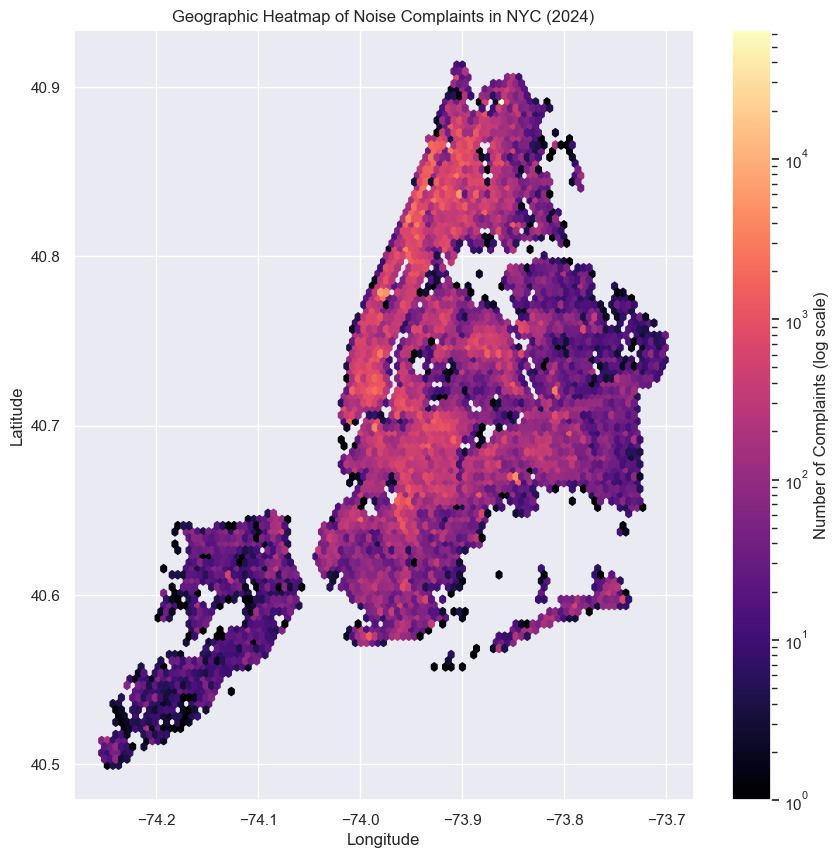

In [51]:
# Geospatial plot

plt.figure(figsize=(10,10))
plt.hexbin(
    noise_df_cleaned["longitude"], 
    noise_df_cleaned["latitude"], 
    gridsize=100, cmap="magma", bins="log"
)
plt.colorbar(label="Number of Complaints (log scale)")
plt.title("Geographic Heatmap of Noise Complaints in NYC (2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


## Geographic Trends
- The spatial heatmap highlights how noise complaints cluster across New York City. Dense concentrations of complaints appear in Manhattan, especially in Midtown and Lower Manhattan, consistent with nightlife, entertainment districts, and high population density. Brooklyn and Queens also show strong clusters, particularly along major residential and commercial corridors.
- In contrast, Staten Island and the outer edges of Queens show much lower complaint density, reflecting their more suburban character. The log scale further reveals that while noise complaints are widespread across the city, the most intense hotspots are concentrated in the urban core where residential life intersects with nightlife and commercial activity.

## Forecasting and Modeling
Forecasting and modeling description

## Conclusions and Next Steps
Forecasting and modeling description